In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import zipfile

In [2]:
torch.manual_seed(42)
np.random.seed(42)

In [3]:
torch.cuda.is_available()

True

In [4]:
# Load training data from subtask1/
def load_subtask1_data():
    with zipfile.ZipFile("train_data.zip", "r") as zf:
        train_data = {}
        for name in zf.namelist():
            if name.startswith("subtask1/") and name.endswith(".npy"):
                with zf.open(name) as f:
                    train_data[name] = np.load(f)
    
    # Concatenate all three scanners
    sub1_X = []
    sub1_y = []
    for s in [1, 2, 3]:
        x = train_data[f"subtask1/scanner{s}_X.npy"].astype(np.float32) / 255.0
        y = train_data[f"subtask1/scanner{s}_y.npy"].astype(np.int64)
        sub1_X.append(x)
        sub1_y.append(y)
    X1 = np.concatenate(sub1_X, axis=0)
    y1 = np.concatenate(sub1_y, axis=0)
    print(X1.shape, y1.shape)
    return X1, y1

In [5]:
# Load training data from subtask2/
def load_subtask2_data():
    with zipfile.ZipFile("train_data.zip", "r") as zf:
        train_data = {}
        for name in zf.namelist():
            if name.startswith("subtask2/") and name.endswith(".npy"):
                with zf.open(name) as f:
                    train_data[name] = np.load(f)

    # Concatenate all eight scanners
    sub2_X = []
    sub2_y = []
    for s in range(1, 9):
        x = train_data[f"subtask2/scanner{s}_X.npy"].astype(np.float32) / 255.0
        y = train_data[f"subtask2/scanner{s}_y.npy"].astype(np.int64)
        sub2_X.append(x)
        sub2_y.append(y)
    X2 = np.concatenate(sub2_X, axis=0)
    y2 = np.concatenate(sub2_y, axis=0)
    print(X2.shape, y2.shape)
    return X2, y2

In [6]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 8, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(8, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(16 * 7 * 7, num_classes),
        )

    def forward(self, x):
        # Handles both 1-ch (subtask1) and 3-ch (subtask2) input.
        # For subtask2, converts RGB to grayscale!
        if x.shape[1] == 3:
            x = 0.299 * x[:, 0:1] + 0.587 * x[:, 1:2] + 0.114 * x[:, 2:3]
        return self.net(x)

In [7]:
def train_model(model, X, y, epochs=300, lr=0.001, batch_size=64):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()

    X_t = torch.from_numpy(X).to(device)
    y_t = torch.from_numpy(y).long().to(device)

    for epoch in range(epochs):
        model.train()
        perm = torch.randperm(len(y))
        total_loss = 0.0
        for start in range(0, len(y), batch_size):
            idx = perm[start:start + batch_size]
            opt.zero_grad()
            loss = loss_fn(model(X_t[idx]), y_t[idx])
            loss.backward()
            opt.step()
            total_loss += loss.item()

        model.eval()
        with torch.no_grad():
            acc = (model(X_t).argmax(1) == y_t).float().mean().item()
        # print(f"  epoch {epoch:2d}: loss={total_loss:.4f}  acc={acc:.4f}")

    model.eval()
    return model.cpu()

In [8]:
X1, y1 = load_subtask1_data()

(1500, 1, 28, 28) (1500,)


In [9]:
X2, y2 = load_subtask2_data()

(4000, 3, 28, 28) (4000,)


In [10]:
# Train Subtask 1 starter model
model1 = SimpleCNN()
params1 = sum(p.numel() for p in model1.parameters())
print(f"  params: {params1:,}")
model1 = train_model(model1, X1, y1)

  params: 9,098
  epoch  0: loss=54.9390  acc=0.1613
  epoch  1: loss=53.1440  acc=0.3240
  epoch  2: loss=48.5193  acc=0.5633
  epoch  3: loss=38.4346  acc=0.7433
  epoch  4: loss=26.6770  acc=0.8173
  epoch  5: loss=18.2250  acc=0.8607
  epoch  6: loss=13.5679  acc=0.9000
  epoch  7: loss=10.5785  acc=0.8933
  epoch  8: loss=9.1799  acc=0.9227
  epoch  9: loss=7.9320  acc=0.9333
  epoch 10: loss=6.6047  acc=0.9347
  epoch 11: loss=6.0572  acc=0.9507
  epoch 12: loss=5.4264  acc=0.9573
  epoch 13: loss=4.7969  acc=0.9613
  epoch 14: loss=4.3362  acc=0.9673
  epoch 15: loss=3.8276  acc=0.9720
  epoch 16: loss=3.5090  acc=0.9733
  epoch 17: loss=3.3203  acc=0.9793
  epoch 18: loss=2.9297  acc=0.9807
  epoch 19: loss=2.6893  acc=0.9800
  epoch 20: loss=2.5257  acc=0.9820
  epoch 21: loss=2.1830  acc=0.9807
  epoch 22: loss=1.9082  acc=0.9887
  epoch 23: loss=1.8365  acc=0.9893
  epoch 24: loss=1.7104  acc=0.9873
  epoch 25: loss=1.5860  acc=0.9927
  epoch 26: loss=1.3542  acc=0.9920
  ep

In [11]:
# Export Subtask 1 model with jit.script
model1.eval();
script1 = torch.jit.script(model1)
torch.jit.save(script1, "model_sub1.pt")
print(f"Exported model_sub1.pt")

Exported model_sub1.pt


In [12]:
# Train Subtask 2 starter model
model2 = SimpleCNN()
params2 = sum(p.numel() for p in model2.parameters())
print(f"  params: {params2:,}")
model2 = train_model(model2, X2, y2)

  params: 9,098
  epoch  0: loss=142.5328  acc=0.2710
  epoch  1: loss=126.4282  acc=0.4068
  epoch  2: loss=105.7708  acc=0.4905
  epoch  3: loss=92.9247  acc=0.5415
  epoch  4: loss=84.8845  acc=0.5678
  epoch  5: loss=79.6780  acc=0.5980
  epoch  6: loss=75.2546  acc=0.6060
  epoch  7: loss=72.4492  acc=0.6173
  epoch  8: loss=70.2203  acc=0.6388
  epoch  9: loss=67.8636  acc=0.6583
  epoch 10: loss=65.7436  acc=0.6530
  epoch 11: loss=63.9243  acc=0.6610
  epoch 12: loss=62.6173  acc=0.6738
  epoch 13: loss=61.2705  acc=0.6640
  epoch 14: loss=60.3851  acc=0.6838
  epoch 15: loss=58.8908  acc=0.6935
  epoch 16: loss=57.6337  acc=0.6953
  epoch 17: loss=56.9220  acc=0.6960
  epoch 18: loss=55.8812  acc=0.7160
  epoch 19: loss=54.4926  acc=0.7155
  epoch 20: loss=53.8006  acc=0.7218
  epoch 21: loss=52.9761  acc=0.7175
  epoch 22: loss=51.9814  acc=0.7225
  epoch 23: loss=51.5857  acc=0.7428
  epoch 24: loss=50.4225  acc=0.7398
  epoch 25: loss=49.7782  acc=0.7435
  epoch 26: loss=48

In [13]:
# Export Subtask 2 model with jit.script
model2.eval();
script2 = torch.jit.script(model2)
torch.jit.save(script2, "model_sub2.pt")
print(f"Exported model_sub2.pt")

Exported model_sub2.pt


In [14]:
# Make zip submission
with zipfile.ZipFile("submission.zip", "w") as zf:
    zf.write("model_sub1.pt")
    zf.write("model_sub2.pt")
print("Wrote submission.zip!")

Wrote submission.zip!


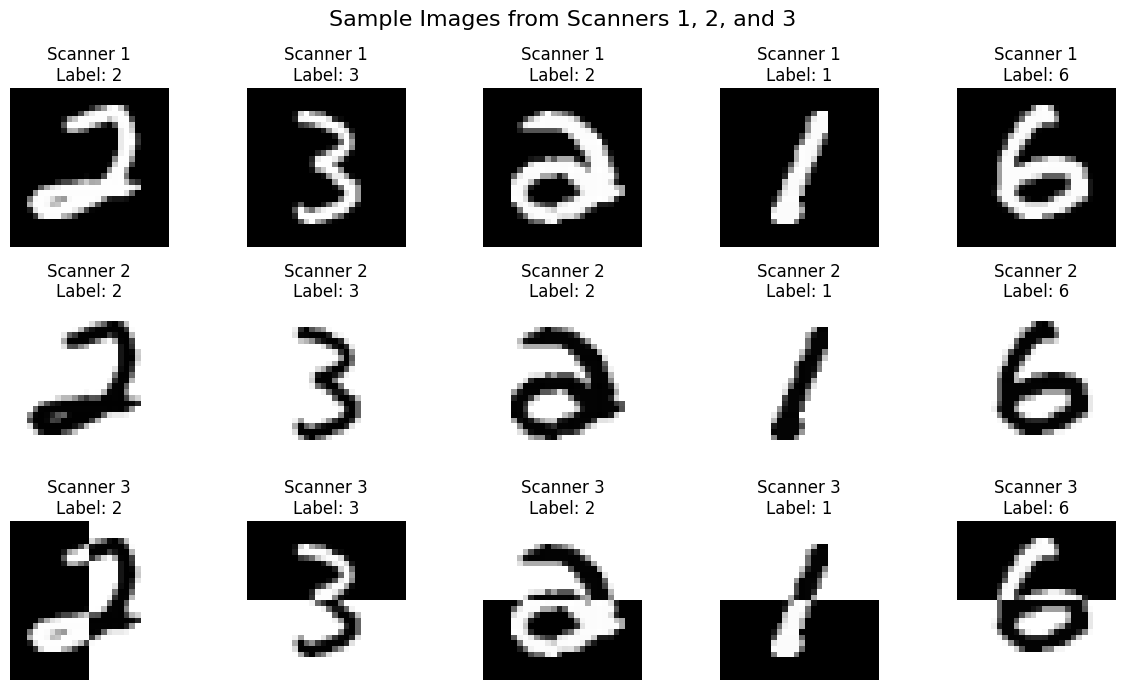

In [15]:
import os
import numpy as np
import matplotlib.pyplot as plt

# Define the updated folder path where your files are located
data_dir = os.path.join('train_data', 'subtask1')

# 1. Load the data from the train_data/subtask1/ directory
scanner1_X = np.load(os.path.join(data_dir, 'scanner1_X.npy'))
scanner1_y = np.load(os.path.join(data_dir, 'scanner1_y.npy'))

scanner2_X = np.load(os.path.join(data_dir, 'scanner2_X.npy'))
scanner2_y = np.load(os.path.join(data_dir, 'scanner2_y.npy'))

scanner3_X = np.load(os.path.join(data_dir, 'scanner3_X.npy'))
scanner3_y = np.load(os.path.join(data_dir, 'scanner3_y.npy'))

# 2. Set up the figure for visualization
num_images_to_show = 5
fig, axes = plt.subplots(3, num_images_to_show, figsize=(12, 7))
fig.suptitle('Sample Images from Scanners 1, 2, and 3', fontsize=16)

# 3. Loop through and plot the images
for i in range(num_images_to_show):
    # Plot for Scanner 1 (Row 0)
    axes[0, i].imshow(scanner1_X[i, 0], cmap='gray')
    axes[0, i].set_title(f"Scanner 1\nLabel: {scanner1_y[i]}")
    axes[0, i].axis('off')
    
    # Plot for Scanner 2 (Row 1)
    axes[1, i].imshow(scanner2_X[i, 0], cmap='gray')
    axes[1, i].set_title(f"Scanner 2\nLabel: {scanner2_y[i]}")
    axes[1, i].axis('off')
    
    # Plot for Scanner 3 (Row 2)
    axes[2, i].imshow(scanner3_X[i, 0], cmap='gray')
    axes[2, i].set_title(f"Scanner 3\nLabel: {scanner3_y[i]}")
    axes[2, i].axis('off')

# Adjust layout and show the plot
plt.tight_layout()
plt.show()